
### **| MBA-DSA USP-ESALQ 2022-2024**
### **| Inteligência Artificial para predição de acidentes de trânsito na rodovia BR-101**
##### **| Análise de dados de acidentes ocorridos entre 2018 e 2023**
###### | Dataset disponível em: <https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf>



### **2 - Aprendizado de Máquina [Learning Algorithm] e 3 - Avaliação dos Modelos [Valuation]**
##### Importação das bibliotecas e do dataset filtrado com dados da BR-101 entre 2018 a 2023

In [1]:
# Importação das Bibliotecas para análise dos dados:
import pandas as pd
import numpy as np

# Plotagem de Dados:
import matplotlib.pyplot as plt
import seaborn as sns

# Aprendizado de Máquina: 

import sklearn
import imblearn


from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Aprendizado de Máquina Regressão Logística: 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, confusion_matrix, roc_curve, auc

# Aprendizado de Máquina Random Forest: 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, jaccard_score, classification_report
from sklearn.tree import plot_tree

#------------------------------------------------------------------------------------------- 
# Conferindo a versão das Bibliotecas que serão utilizas:
print("Scikit-learn version:", sklearn.__version__)
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Imbalanced-learn version:", imblearn.__version__)



Scikit-learn version: 1.3.0
Pandas version: 2.0.3
Numpy version: 1.24.3
Imbalanced-learn version: 0.12.3


In [2]:
#Importação do dataset filtrado com dados da BR-101 entre 2018 a 2023:
df_copia = pd.read_csv('C:/Users/filipe/anaconda3/envs/tccdsa1/projetof/util/001PreProcessamento/002Filtragem_e_analise_exploratória_de_dados/df_copia.csv', sep=',', encoding='utf-8', low_memory=False)
#df_filtrado101 = pd.read_csv('C:/Users/filipe/anaconda3/envs/tccdsa1/ProjetoF2/df_filtrado101.csv', sep=',', encoding='utf-8', low_memory=False)

# Imprimir a quantidade de linhas e colunas:
print(f"Shape: O DataFrame possui {df_copia.shape[0]} linhas e {df_copia.shape[1]} colunas.\n")

# Exibindo informações gerais sobre o dataset:
#print(df_copia.info())

# Visualizando as primeiras linhas do dataset
#print(df_copia.head())

Shape: O DataFrame possui 288010 linhas e 26 colunas.



### 2.1 - Modelo de **Regressão Logística Multinomial** usando **Grid Search**
##### Separação dos conjuntos de dados de Treinamento e de Teste: 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from collections import Counter

# Convertendo a coluna 'data_inversa' para datetime
df_copia['data_inversa'] = pd.to_datetime(df_copia['data_inversa'])
df_copia['ano'] = df_copia['data_inversa'].dt.year.astype(int)

# Filtrando os dados para o período de 2018 a 2023
df_copia = df_copia[df_copia['ano'].between(2018, 2023)]

# Definição das variáveis de entrada e saída
features = ['dia_semana', 'horario', 'uf', 'km', 'municipio', 'causa_acidente', 
            'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 
            'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 
            'tipo_veiculo', 'tipo_envolvido', 'idade', 'sexo', 'latitude', 'longitude', 'ano']
X = df_copia[features]

# Criando a variável de saída com quatro classes
conditions = [
    (df_copia['feridos_leves'] > 0),
    (df_copia['feridos_graves'] > 0),
    (df_copia['mortos'] > 0),
    (df_copia['ilesos'] > 0)
]
choices = [0, 1, 2, 3]
df_copia['class'] = np.select(conditions, choices, default=3)
y = df_copia['class']

# Transformação de dados categóricos em numéricos
encoder = LabelEncoder()
for column in features:
    X[column] = encoder.fit_transform(X[column])

# Normalização dos dados
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Separação dos dados de treinamento e teste com estratificação
train_data = df_copia[(df_copia['ano'] >= 1/2018) & (df_copia['ano'] <= 10/2021)]
test_data = df_copia[(df_copia['ano'] >= 11/2021) & (df_copia['ano'] <= 8/2023)]

X_train = train_data[features]
y_train = train_data['class']
X_test = test_data[features]
y_test = test_data['class']

# Separação dos dados em treinamento e teste, garantindo representatividade temporal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Verificar distribuição das classes antes e depois do split
print("Distribuição das classes no conjunto total:", Counter(y))
print("Distribuição das classes no treinamento:", Counter(y_train))
print("Distribuição das classes no teste:", Counter(y_test))

# Definição do modelo Logistic Regression com balanceamento de classes
logistic_model = LogisticRegression(class_weight='balanced', multi_class='multinomial', solver='lbfgs')

# Definição dos hiperparâmetros para otimização
param_grid = {'C': [0.1, 1, 10, 100], 'penalty': ['l2']}

# Aplicação do Grid Search com validação cruzada
grid_search = GridSearchCV(logistic_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Melhor modelo encontrado pelo Grid Search
best_model = grid_search.best_estimator_

# Previsões
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Resultados
print("Melhor modelo encontrado:", best_model)


# Imprimindo o tamanho dos dados de treinamento e de teste
print(f"Tamanho dos dados de treinamento: {X_train.shape[0]}")
print(f"Tamanho dos dados de teste: {X_test.shape[0]}")


C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\368344167.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = encoder.fit_transform(X[column])
C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\368344167.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = encoder.fit_transform(X[column])
C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\368344167.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

Distribuição das classes no conjunto total: Counter({3: 145517, 0: 99758, 1: 33388, 2: 9347})
Distribuição das classes no treinamento: Counter({3: 101862, 0: 69831, 1: 23371, 2: 6543})
Distribuição das classes no teste: Counter({3: 43655, 0: 29927, 1: 10017, 2: 2804})


c:\Users\filipe\anaconda3\envs\nome_do_seu_env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\filipe\anaconda3\envs\nome_do_seu_env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/lin

Melhor modelo encontrado: LogisticRegression(C=100, class_weight='balanced', multi_class='multinomial')
Tamanho dos dados de treinamento: 201607
Tamanho dos dados de teste: 86403


c:\Users\filipe\anaconda3\envs\nome_do_seu_env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, jaccard_score
from sklearn.model_selection import cross_val_score

# Validação Cruzada - Média e Desvio Padrão das Acurácias
cv_scores_rlm = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')

print("\nValidação Cruzada - Regressão Logística Multinomial:")
print(f"Acurácias: {cv_scores_rlm}")
print(f"Média da Acurácia: {cv_scores_rlm.mean():.4f}")
print(f"Desvio Padrão da Acurácia: {cv_scores_rlm.std():.4f}")

# Relatório detalhado por classe para treinamento e teste
print("\nRelatório de Classificação - Regressão Logística Multinomial (Treinamento):")
print(classification_report(y_train, y_train_pred, digits=4))

print("\nRelatório de Classificação - Regressão Logística Multinomial (Teste):")
print(classification_report(y_test, y_test_pred, digits=4))

# Cálculo do erro por classe (1 - acurácia)
errors_train_rlm = 1 - accuracy_score(y_train, y_train_pred)
errors_test_rlm = 1 - accuracy_score(y_test, y_test_pred)

# Exibição dos erros
print("\nErro - Regressão Logística Multinomial:")
print(f"Erro no treinamento: {errors_train_rlm:.4f}")
print(f"Erro no teste: {errors_test_rlm:.4f}")

# Cálculo das métricas médias no treinamento e teste
metrics = ['precision', 'recall', 'f1', 'jaccard']
metric_values_rlm = {
    'Treinamento': [
        precision_score(y_train, y_train_pred, average='weighted'),
        recall_score(y_train, y_train_pred, average='weighted'),
        f1_score(y_train, y_train_pred, average='weighted'),
        jaccard_score(y_train, y_train_pred, average='weighted')
    ],
    'Teste': [
        precision_score(y_test, y_test_pred, average='weighted'),
        recall_score(y_test, y_test_pred, average='weighted'),
        f1_score(y_test, y_test_pred, average='weighted'),
        jaccard_score(y_test, y_test_pred, average='weighted')
    ]
}

print("\nMédias das métricas - Regressão Logística Multinomial:")
for metric, train_value, test_value in zip(metrics, metric_values_rlm['Treinamento'], metric_values_rlm['Teste']):
    print(f"{metric.capitalize()} - Treinamento: {train_value:.4f}, Teste: {test_value:.4f}")

# Parâmetros ajustados pelo GridSearchCV
print("\nParâmetros ajustados para Regressão Logística Multinomial:")
print(grid_search.best_params_)







c:\Users\filipe\anaconda3\envs\nome_do_seu_env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\filipe\anaconda3\envs\nome_do_seu_env\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/lin


Validação Cruzada - Regressão Logística Multinomial:
Acurácias: [0.55994246 0.55728882 0.55546737 0.55494655 0.55499616]
Média da Acurácia: 0.5565
Desvio Padrão da Acurácia: 0.0019

Relatório de Classificação - Regressão Logística Multinomial (Treinamento):
              precision    recall  f1-score   support

           0     0.5857    0.3995    0.4750     69831
           1     0.2185    0.3424    0.2668     23371
           2     0.3288    0.9997    0.4949      6543
           3     0.7160    0.6851    0.7002    101862

    accuracy                         0.5566    201607
   macro avg     0.4623    0.6067    0.4842    201607
weighted avg     0.6006    0.5566    0.5653    201607


Relatório de Classificação - Regressão Logística Multinomial (Teste):
              precision    recall  f1-score   support

           0     0.5850    0.3967    0.4728     29927
           1     0.2168    0.3391    0.2645     10017
           2     0.3300    1.0000    0.4962      2804
           3     0

### 3.1 - Avaliação do Modelo de **Regressão Logística** [Evaluation]:
##### Resultados do modelo usando **Regressão Logística** e **GridSearch**: Matriz de confusão,  Precisão, Acurácia, Overfitting...: 

Médias das métricas de Regressão Logística Multinomial - Treinamento:
Acurácia: 0.5566473386340752
Precisão: 0.6006350137506523
Recall: 0.5566473386340752
F1 Score: 0.5652934610608217
Índice de Jaccard: 0.40858174162378147

Médias das métricas de Regressão Logística Multinomial - Teste:
Acurácia: 0.5562191127622883
Precisão: 0.5996870724709517
Recall: 0.5562191127622883
F1 Score: 0.564514611892191
Índice de Jaccard: 0.4080355183358376

Comparação de Métricas:
Overfitting - Regressão Logística Multinomial: 0.00042822587178692473
Matriz de Confusão - Regressão Logística Multinomial:
Esses valores representam a performance do modelo em cada classe:
Classe 0 (Feridos Leves); Classe 1 (Feridos Graves); Classe 2 (Mortos); Classe 3 (Ilesos);


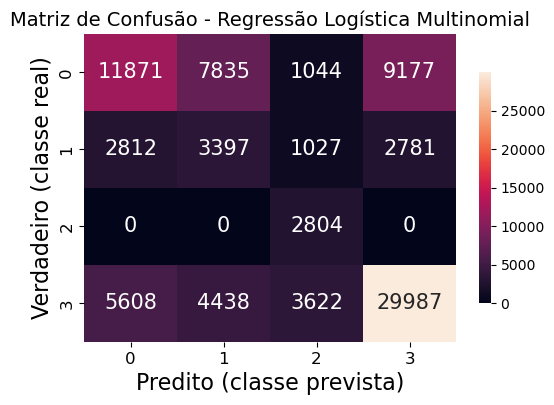

Matriz de Confusão - Regressão Logística:
[[11871  7835  1044  9177]
 [ 2812  3397  1027  2781]
 [    0     0  2804     0]
 [ 5608  4438  3622 29987]]


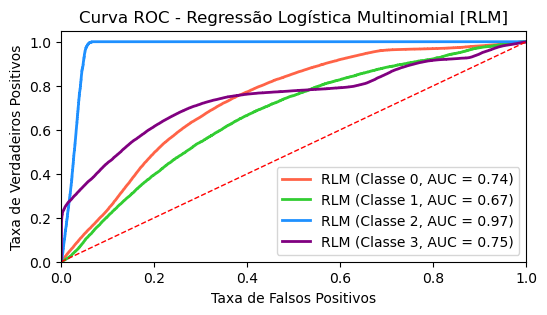

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Dados previamente preparados e modelo treinado conforme o código fornecido anteriormente

# Avaliação do modelo nos dados de treinamento
accuracy_train = accuracy_score(y_train, y_train_pred)
precision_train = precision_score(y_train, y_train_pred, average='weighted')
recall_train = recall_score(y_train, y_train_pred, average='weighted')
f1_train = f1_score(y_train, y_train_pred, average='weighted')
jaccard_train = jaccard_score(y_train, y_train_pred, average='weighted')

# Avaliação do modelo nos dados de teste
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred, average='weighted')
recall_test = recall_score(y_test, y_test_pred, average='weighted')
f1_test = f1_score(y_test, y_test_pred, average='weighted')
jaccard_test = jaccard_score(y_test, y_test_pred, average='weighted')

# Verificação de overfitting
overfitting = accuracy_train - accuracy_test

print("Médias das métricas de Regressão Logística Multinomial - Treinamento:")
print(f"Acurácia: {accuracy_train}")
print(f"Precisão: {precision_train}")
print(f"Recall: {recall_train}")
print(f"F1 Score: {f1_train}")
print(f"Índice de Jaccard: {jaccard_train}")

print("\nMédias das métricas de Regressão Logística Multinomial - Teste:")
print(f"Acurácia: {accuracy_test}")
print(f"Precisão: {precision_test}")
print(f"Recall: {recall_test}")
print(f"F1 Score: {f1_test}")
print(f"Índice de Jaccard: {jaccard_test}")

# Análise de Overfitting
print("\nComparação de Métricas:")
print(f"Overfitting - Regressão Logística Multinomial: {overfitting}")



# Matriz de confusão
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Matriz de Confusão - Regressão Logística Multinomial:")
print("Esses valores representam a performance do modelo em cada classe:")
print("Classe 0 (Feridos Leves); Classe 1 (Feridos Graves); Classe 2 (Mortos); Classe 3 (Ilesos);")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', annot_kws={"size": 15}, cbar_kws={"shrink": .75})
plt.xlabel('Predito (classe prevista)', fontsize=16)
plt.ylabel('Verdadeiro (classe real)', fontsize=16)
plt.title('Matriz de Confusão - Regressão Logística Multinomial', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Matriz de confusão
conf_matrix = confusion_matrix(y_test, y_test_pred)
print("Matriz de Confusão - Regressão Logística:")
print(conf_matrix)

# Curva ROC para Regressão Logística Multinomial
y_prob = best_model.predict_proba(X_test)
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(6, 3))
colors = ['#FF6347', '#32CD32', '#1E90FF', '#800080']  # Quatro cores diferentes
for i, color in zip(range(len(best_model.classes_)), colors):
    fpr[i], tpr[i], _ = roc_curve(y_test, y_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, color=color, label=f'RLM (Classe {i}, AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Regressão Logística Multinomial [RLM]')
plt.legend(loc="lower right", fontsize=10)  # Ajuste do tamanho da legenda
plt.show()


### 2.2 - Modelo usando **Random Forest**
##### Separação dos conjuntos de dados de Treinamento e de Teste: 


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from collections import Counter

# Convertendo a coluna 'data_inversa' para datetime
df_copia['data_inversa'] = pd.to_datetime(df_copia['data_inversa'])
df_copia['ano'] = df_copia['data_inversa'].dt.year.astype(int)

# Filtrando os dados para o período de 2018 a 2023
df_copia = df_copia[df_copia['ano'].between(2018, 2023)]

# Definição das variáveis de entrada e saída
features = ['dia_semana', 'horario', 'uf', 'km', 'municipio', 'causa_acidente', 
            'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 
            'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 
            'tipo_veiculo', 'tipo_envolvido', 'idade', 'sexo', 'latitude', 'longitude', 'ano']
X = df_copia[features]

# Criando a variável de saída com quatro classes
conditions = [
    (df_copia['feridos_leves'] > 0),
    (df_copia['feridos_graves'] > 0),
    (df_copia['mortos'] > 0),
    (df_copia['ilesos'] > 0)
]
choices = [0, 1, 2, 3]
df_copia['class'] = np.select(conditions, choices, default=3)
y = df_copia['class']

# Transformação de dados categóricos em numéricos
encoder = LabelEncoder()
for column in features:
    X[column] = encoder.fit_transform(X[column])

# Normalização dos dados
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


# Separação dos dados de treinamento e teste com estratificação
train_data = df_copia[(df_copia['ano'] >= 1/2018) & (df_copia['ano'] <= 10/2021)]
test_data = df_copia[(df_copia['ano'] >= 11/2021) & (df_copia['ano'] <= 8/2023)]

X_train = train_data[features]
y_train = train_data['class']
X_test = test_data[features]
y_test = test_data['class']


# Separação dos dados em treinamento e teste, garantindo representatividade temporal
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Verificar distribuição das classes antes e depois do split
print("Distribuição das classes no conjunto total:", Counter(y))
print("Distribuição das classes no treinamento:", Counter(y_train))
print("Distribuição das classes no teste:", Counter(y_test))


# Aplicando regularização no Random Forest para reduzir overfitting
random_forest_model = RandomForestClassifier(
    class_weight='balanced',        # Para lidar com desbalanceamento de classes
    random_state=42,                # Reprodutibilidade
    max_depth=15,                   # Limitar a profundidade máxima das árvores
    min_samples_leaf=4,             # Definir o número mínimo de amostras por folha
    n_estimators=100                # Quantidade de árvores no modelo
)
random_forest_model.fit(X_train, y_train)


# Treinando o modelo Random Forest com balanceamento de classes
random_forest_model = RandomForestClassifier(class_weight='balanced', random_state=42)
random_forest_model.fit(X_train, y_train)

# Previsões
y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

# Imprimindo o tamanho dos dados de treinamento e de teste
print(f"Tamanho dos dados de treinamento: {X_train.shape[0]}")
print(f"Tamanho dos dados de teste: {X_test.shape[0]}")

# Exibindo resultados
print("Random Forest treinado!")



C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\3679116191.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = encoder.fit_transform(X[column])
C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\3679116191.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = encoder.fit_transform(X[column])
C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\3679116191.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

Distribuição das classes no conjunto total: Counter({3: 145517, 0: 99758, 1: 33388, 2: 9347})
Distribuição das classes no treinamento: Counter({3: 101862, 0: 69831, 1: 23371, 2: 6543})
Distribuição das classes no teste: Counter({3: 43655, 0: 29927, 1: 10017, 2: 2804})
Tamanho dos dados de treinamento: 201607
Tamanho dos dados de teste: 86403
Random Forest treinado!


In [ ]:
# Validação Cruzada - Média e Desvio Padrão das Acurácias
cv_scores_rf = cross_val_score(random_forest_model, X_train, y_train, cv=5, scoring='accuracy')

print("\nValidação Cruzada - Random Forest:")
print(f"Acurácias: {cv_scores_rf}")
print(f"Média da Acurácia: {cv_scores_rf.mean():.4f}")
print(f"Desvio Padrão da Acurácia: {cv_scores_rf.std():.4f}")

# Relatório detalhado por classe para treinamento e teste
print("\nRelatório de Classificação - Random Forest (Treinamento):")
print(classification_report(y_train, y_train_pred_rf, digits=4))

print("\nRelatório de Classificação - Random Forest (Teste):")
print(classification_report(y_test, y_test_pred_rf, digits=4))

# Cálculo do erro por classe (1 - acurácia)
errors_train_rf = 1 - accuracy_score(y_train, y_train_pred_rf)
errors_test_rf = 1 - accuracy_score(y_test, y_test_pred_rf)

# Exibição dos erros
print("\nErro - Random Forest:")
print(f"Erro no treinamento: {errors_train_rf:.4f}")
print(f"Erro no teste: {errors_test_rf:.4f}")

# Cálculo das métricas médias no treinamento e teste
metric_values_rf = {
    'Treinamento': [
        precision_score(y_train, y_train_pred_rf, average='weighted'),
        recall_score(y_train, y_train_pred_rf, average='weighted'),
        f1_score(y_train, y_train_pred_rf, average='weighted'),
        jaccard_score(y_train, y_train_pred_rf, average='weighted')
    ],
    'Teste': [
        precision_score(y_test, y_test_pred_rf, average='weighted'),
        recall_score(y_test, y_test_pred_rf, average='weighted'),
        f1_score(y_test, y_test_pred_rf, average='weighted'),
        jaccard_score(y_test, y_test_pred_rf, average='weighted')
    ]
}

print("\nMédias das métricas - Random Forest:")
for metric, train_value, test_value in zip(metrics, metric_values_rf['Treinamento'], metric_values_rf['Teste']):
    print(f"{metric.capitalize()} - Treinamento: {train_value:.4f}, Teste: {test_value:.4f}")

# Visualização dos parâmetros ajustados no Random Forest
print("\nParâmetros ajustados para Random Forest:")
print(random_forest_model.get_params())



Validação Cruzada - Random Forest:
Acurácias: [0.86659888 0.86268042 0.8622058  0.86332184 0.86037053]
Média da Acurácia: 0.8630
Desvio Padrão da Acurácia: 0.0020

Relatório de Classificação - Random Forest (Treinamento):
              precision    recall  f1-score   support

           0     0.9989    0.9988    0.9989     69831
           1     0.9969    0.9989    0.9979     23371
           2     0.9939    1.0000    0.9970      6543
           3     0.9997    0.9990    0.9993    101862

    accuracy                         0.9989    201607
   macro avg     0.9974    0.9992    0.9983    201607
weighted avg     0.9989    0.9989    0.9989    201607


Relatório de Classificação - Random Forest (Teste):
              precision    recall  f1-score   support

           0     0.8141    0.8777    0.8447     29927
           1     0.8941    0.5869    0.7087     10017
           2     0.9008    0.9169    0.9088      2804
           3     0.9126    0.9347    0.9235     43655

    accuracy     

### 3.2 - Avaliação do Modelo **Random Forest** [Evaluation]
##### Matriz de confusão,  Precisão, Acurácia, Overfitting...: 

Média das métricas de Random Forest - Treinamento:
Acurácia: 0.9989286086296607
Precisão: 0.9989303858522236
Recall: 0.9989286086296607
F1 Score: 0.9989290021508748
Índice de Jaccard: 0.9978609657130003

Médias das métricas de Random Forest - Teste:
Acurácia: 0.8740437253336111
Precisão: 0.8759760267595564
Recall: 0.8740437253336111
F1 Score: 0.8708331137070658
Índice de Jaccard: 0.7773524575128598

Comparação de Métricas:
Overfitting - Random Forest: 0.12488488329604963
Matriz de Confusão - Random Forest:
Esses valores representam a performance do modelo em cada classe: 
Classe 0 (Feridos Leves); Classe 1 (Feridos Graves); Classe 2 (Mortos); Classe 3 (Ilesos);


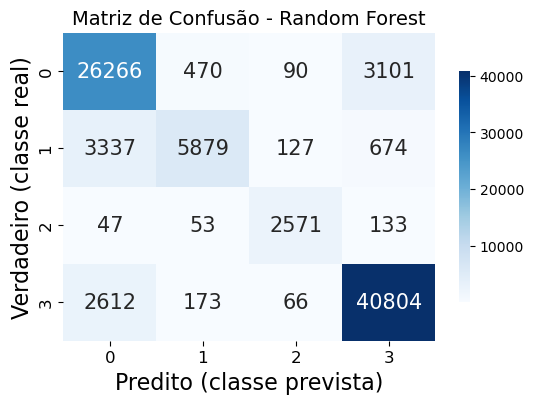

Matriz de Confusão - Random Forest:
[[26266   470    90  3101]
 [ 3337  5879   127   674]
 [   47    53  2571   133]
 [ 2612   173    66 40804]]


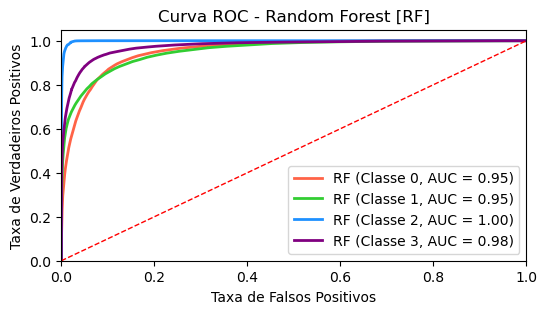

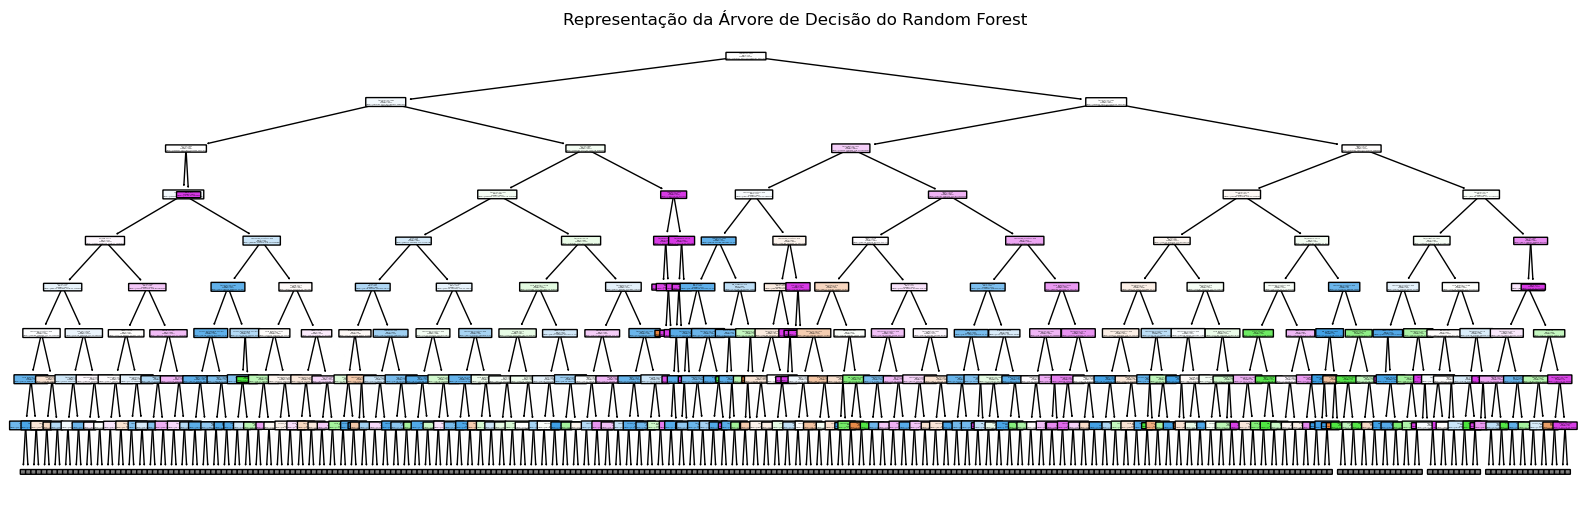

In [8]:
# Avaliação do modelo nos dados de treinamento
accuracy_train_rf = accuracy_score(y_train, y_train_pred_rf)
precision_train_rf = precision_score(y_train, y_train_pred_rf, average='weighted')
recall_train_rf = recall_score(y_train, y_train_pred_rf, average='weighted')
f1_train_rf = f1_score(y_train, y_train_pred_rf, average='weighted')
jaccard_train_rf = jaccard_score(y_train, y_train_pred_rf, average='weighted')

# Avaliação do modelo nos dados de teste
accuracy_test_rf = accuracy_score(y_test, y_test_pred_rf)
precision_test_rf = precision_score(y_test, y_test_pred_rf, average='weighted')
recall_test_rf = recall_score(y_test, y_test_pred_rf, average='weighted')
f1_test_rf = f1_score(y_test, y_test_pred_rf, average='weighted')
jaccard_test_rf = jaccard_score(y_test, y_test_pred_rf, average='weighted')

print("Média das métricas de Random Forest - Treinamento:")
print(f"Acurácia: {accuracy_train_rf}")
print(f"Precisão: {precision_train_rf}")
print(f"Recall: {recall_train_rf}")
print(f"F1 Score: {f1_train_rf}")
print(f"Índice de Jaccard: {jaccard_train_rf}")

print("\nMédias das métricas de Random Forest - Teste:")
print(f"Acurácia: {accuracy_test_rf}")
print(f"Precisão: {precision_test_rf}")
print(f"Recall: {recall_test_rf}")
print(f"F1 Score: {f1_test_rf}")
print(f"Índice de Jaccard: {jaccard_test_rf}")

# Verificação de overfitting
overfitting_rf = (accuracy_train_rf - accuracy_test_rf)

# Análise de Overfitting
print("\nComparação de Métricas:")
print(f"Overfitting - Random Forest: {overfitting_rf}")


# Matriz de confusão
conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
print("Matriz de Confusão - Random Forest:")
print("Esses valores representam a performance do modelo em cada classe: ")
print("Classe 0 (Feridos Leves); Classe 1 (Feridos Graves); Classe 2 (Mortos); Classe 3 (Ilesos);")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 15}, cbar_kws={"shrink": .75})
plt.xlabel('Predito (classe prevista)', fontsize=16)
plt.ylabel('Verdadeiro (classe real)', fontsize=16)
plt.title('Matriz de Confusão - Random Forest', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Matriz de confusão
conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
print("Matriz de Confusão - Random Forest:")
print(conf_matrix_rf)

# Curva ROC para Random Forest
y_prob_rf = random_forest_model.predict_proba(X_test)
fpr_rf = {}
tpr_rf = {}
roc_auc_rf = {}

plt.figure(figsize=(6, 3))
colors = ['#FF6347', '#32CD32', '#1E90FF', '#800080']  # Quatro cores diferentes
for i, color in zip(range(len(random_forest_model.classes_)), colors):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test, y_prob_rf[:, i], pos_label=i)
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])
    plt.plot(fpr_rf[i], tpr_rf[i], lw=2, color=color, label=f'RF (Classe {i}, AUC = {roc_auc_rf[i]:.2f})')

plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Random Forest [RF]')
plt.legend(loc="lower right", fontsize=10)  # tamanho da legenda
plt.show()

# Plotando uma das árvores de decisão do Random Forest
plt.figure(figsize=(20, 6))
from sklearn.tree import plot_tree
plot_tree(random_forest_model.estimators_[41], feature_names=features, filled=True, rounded=True, class_names=['Feridos Leves', 'Feridos Graves', 'Mortos', 'Ilesos'], max_depth=8)
plt.title('Representação da Árvore de Decisão do Random Forest')
plt.show()


Verificando a relevância das variáveis - Imporância das features 

C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\2536344834.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = encoder.fit_transform(X[column])
C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\2536344834.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[column] = encoder.fit_transform(X[column])
C:\Users\filipe\AppData\Local\Temp\ipykernel_6444\2536344834.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

<Figure size 1500x300 with 0 Axes>

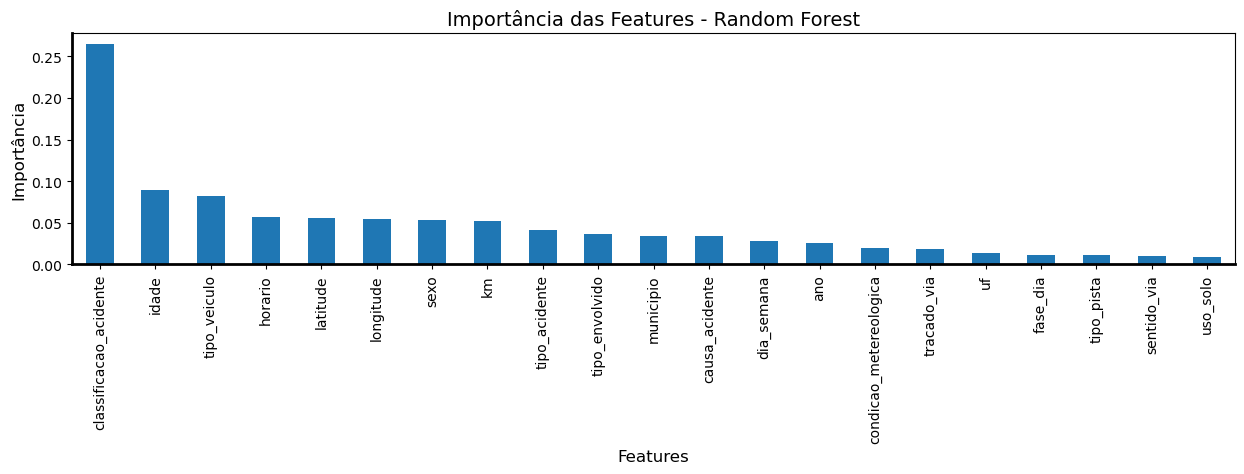

In [9]:
# Preprocessamento de dados
df_copia['data_inversa'] = pd.to_datetime(df_copia['data_inversa'])
df_copia['ano'] = df_copia['data_inversa'].dt.year.astype(int)
df_copia = df_copia[df_copia['ano'].between(2018, 2023)]

# Definindo variáveis de entrada (features) e de saída (target)
features = ['dia_semana', 'horario', 'uf', 'km', 'municipio', 'causa_acidente', 
            'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 
            'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 
            'tipo_veiculo', 'tipo_envolvido', 'idade', 'sexo', 'latitude', 'longitude', 'ano']
X = df_copia[features]

# Criando a variável de saída com quatro classes
conditions = [
    (df_copia['feridos_leves'] > 0),
    (df_copia['feridos_graves'] > 0),
    (df_copia['mortos'] > 0),
    (df_copia['ilesos'] > 0)
]
choices = [0, 1, 2, 3]  # 0: feridos leves, 1: feridos graves, 2: mortos, 3: ilesos
df_copia['class'] = np.select(conditions, choices, default=3)
y = df_copia['class']

# Transformação das variáveis categóricas em numéricas
encoder = LabelEncoder()
for column in features:
    X[column] = encoder.fit_transform(X[column])

# Normalizando os dados
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Separando os dados em treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Treinando o modelo Random Forest
random_forest_model = RandomForestClassifier(class_weight='balanced', random_state=42)
random_forest_model.fit(X_train, y_train)

# Determinação da importância das features
importancia_input = pd.DataFrame({'importance': random_forest_model.feature_importances_}, index=features)
importancia_input.sort_values(by='importance', ascending=False, inplace=True)

# Plotando a importância das features com eixos mais grossos
plt.figure(figsize=(15, 3))
importancia_input.plot(kind='bar', figsize=(15, 3), legend=False)

# Configurações dos eixos
plt.title('Importância das Features - Random Forest', fontsize=14)
plt.ylabel('Importância', fontsize=12)
plt.xlabel('Features', fontsize=12)

# Aumentando a grossura dos eixos X e Y
plt.gca().spines['bottom'].set_linewidth(2)  
plt.gca().spines['left'].set_linewidth(2)    

# Ajuste do tamanho dos ticks dos eixos
plt.tick_params(axis='x', labelsize=10, rotation=90)  # Rotação para melhor leitura das features
plt.tick_params(axis='y', labelsize=10)

plt.show()
